<a href="https://colab.research.google.com/github/smaranikaduttapattanaik/entity-aware-text-summarization/blob/main/entity_aware_text_summarization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 (Module 1): Information Extraction + Summarization
## Financial News → Structured Insights + Summaries

### Objective
This project implements a full NLP pipeline on financial news articles to:
1. **Extract Named Entities** (companies, dates, events) using spaCy
2. **Extract Relations** (e.g., company → acquisition → company) using pattern-based methods + entity pairing
3. **Generate Abstractive Summaries** using BART (pretrained) and an entity-guided pipeline
4. **Evaluate** using ROUGE scores and Entity Coverage

### Datasets
- **Kaggle Financial News Dataset** (`Financial.csv`) — for NER + Relation Extraction
- **CNN/DailyMail Dataset** (HuggingFace) — for summarization evaluation

---

---
## Section 1: Environment Setup

In [ ]:
# Install required libraries
!pip install datasets spacy rouge-score --quiet
!python -m spacy download en_core_web_trf --quiet

# Pin transformers to a stable version compatible with this pipeline
!pip uninstall -y transformers --quiet
!pip install transformers==4.41.2 --quiet

print("✅ All packages installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.4/457.4 MB 719.2 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All packages installed successfully.


In [ ]:
# Standard library
import re
import time
from collections import Counter

# Data handling
import pandas as pd
import matplotlib.pyplot as plt

# NLP
import spacy
from transformers import pipeline
from datasets import load_dataset
from rouge_score import rouge_scorer

print("✅ All imports successful.")

✅ All imports successful.


---
## Section 2: Data Loading
Load the Financial News dataset (Kaggle) and the CNN/DailyMail dataset (HuggingFace).

In [ ]:
# Upload Financial.csv
from google.colab import files
uploaded = files.upload()

Saving Financial.csv to Financial (1).csv


In [ ]:
# Error handling for CSV loading
try:
    df = pd.read_csv("Financial.csv")
    print(f"✅ Dataset loaded successfully.")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print("\n--- First 5 rows ---")
    print(df.head())
    print("\n--- Sample Article (first 500 chars) ---")
    print(df['Content'][0][:500])
except FileNotFoundError:
    print("❌ ERROR: 'Financial.csv' not found. Please upload the file correctly.")
    raise
except Exception as e:
    print(f"❌ ERROR loading dataset: {e}")
    raise

✅ Dataset loaded successfully.
Dataset shape: (15534, 3)
Columns: ['Title', 'Tag', 'Content']

--- First 5 rows ---
                                   Title           Tag  \
0  TSX Slightly Down, Books Weekly Gains  Stock Market   
1          UnitedHealth Hits 4-week High        stocks   
2          Cisco Systems Hits 4-week Low        stocks   
3                 AT&T Hits All-time Low        stocks   
4             Microsoft Hits 4-week High        stocks   

                                             Content  
0  TSX Slightly Down, Books Weekly GainsUnited St...  
1  UnitedHealth Hits 4-week HighUnited States sto...  
2  Cisco Systems Hits 4-week LowUnited States sto...  
3  AT&T Hits All-time LowUnited States stocksAT&T...  
4  Microsoft Hits 4-week HighUnited States stocks...  

--- Sample Article (first 500 chars) ---
TSX Slightly Down, Books Weekly GainsUnited States Stock MarketThe S&P/TSX Composite index ended marginally in the red at the 20,260 level on Friday, the highest s

In [ ]:
# Load CNN/DailyMail dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")
cnn_data = dataset['train'].select(range(10))  # Using 10 samples

print(f"CNN/DailyMail loaded: {len(cnn_data)} samples")
print("\n--- Sample Article ---")
print(cnn_data[0]['article'][:300])
print("\n--- Reference Highlights ---")
print(cnn_data[0]['highlights'])

CNN/DailyMail loaded: 10 samples

--- Sample Article ---
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappoi

--- Reference Highlights ---
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


---
## Section 3: Preprocessing

In [ ]:
def clean_text(text):
    """
    Clean financial news text:
    - Collapse multiple whitespace into single spaces
    - Insert period between camelCase boundaries (common in scraped data)
    """
    text = re.sub(r'\s+', ' ', str(text))                  # Normalize whitespace
    text = re.sub(r'([a-z])([A-Z])', r'\1. \2', text)      # Fix missing sentence breaks
    return text.strip()

df['clean_content'] = df['Content'].apply(clean_text)

print("✅ Text cleaning applied to all articles.")

print("\n--- BEFORE CLEANING (first 300 chars) ---")
print(df['Content'][0][:300])
print("\n--- AFTER CLEANING (first 300 chars) ---")
print(df['clean_content'][0][:300])

✅ Text cleaning applied to all articles.

--- BEFORE CLEANING (first 300 chars) ---
TSX Slightly Down, Books Weekly GainsUnited States Stock MarketThe S&P/TSX Composite index ended marginally in the red at the 20,260 level on Friday, the highest since late May, snapping the sharp gains from the prior three sessions while adding 2.2% on the week amid continuous hopes that lower infl

--- AFTER CLEANING (first 300 chars) ---
TSX Slightly Down, Books Weekly Gains. United States Stock Market. The S&P/TSX Composite index ended marginally in the red at the 20,260 level on Friday, the highest since late May, snapping the sharp gains from the prior three sessions while adding 2.2% on the week amid continuous hopes that lower 


---
## Section 4: Model Loading
Load spaCy (NER) and BART (Summarization) models.

In [ ]:
# Load spaCy transformer model for Named Entity Recognition
nlp = spacy.load("en_core_web_trf")

# Load BART model for abstractive summarization
# facebook/bart-large-cnn is fine-tuned on CNN/DailyMail — ideal for news summarization
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

print("✅ spaCy NER model loaded:", nlp.meta['name'])
print("✅ BART summarization pipeline ready.")

✅ spaCy NER model loaded: core_web_trf
✅ BART summarization pipeline ready.


---
## Section 5: Named Entity Recognition (NER)
Extract entities using spaCy focusing on ORG, GPE, PERSON, DATE and EVENT labels.

In [ ]:
# Demo NER on a single article
sample_text = df['clean_content'][0]
doc = nlp(sample_text)

print("--- Named Entities Found ---")
for ent in doc.ents:
    print(f"  [{ent.label_}] {ent.text}")

--- Named Entities Found ---
  [DATE] Weekly
  [GPE] United States
  [CARDINAL] 20,260
  [DATE] Friday
  [DATE] late May
  [CARDINAL] three
  [PERCENT] 2.2%
  [DATE] the week
  [PERCENT] 2.3%
  [PERCENT] 0.2%
  [ORG] Nasdaq
  [PERCENT] 0.3%
  [GPE] US
  [ORG] TELUS International
  [PERCENT] 30.5%
  [DATE] second quarter
  [ORG] Pine Cliff Energy
  [PERCENT] 6.9%
  [ORG] Stifel
  [ORG] First Quantum Minerals
  [PERCENT] 0.7%
  [ORG] Raymond James
  [DATE] 2 days ago


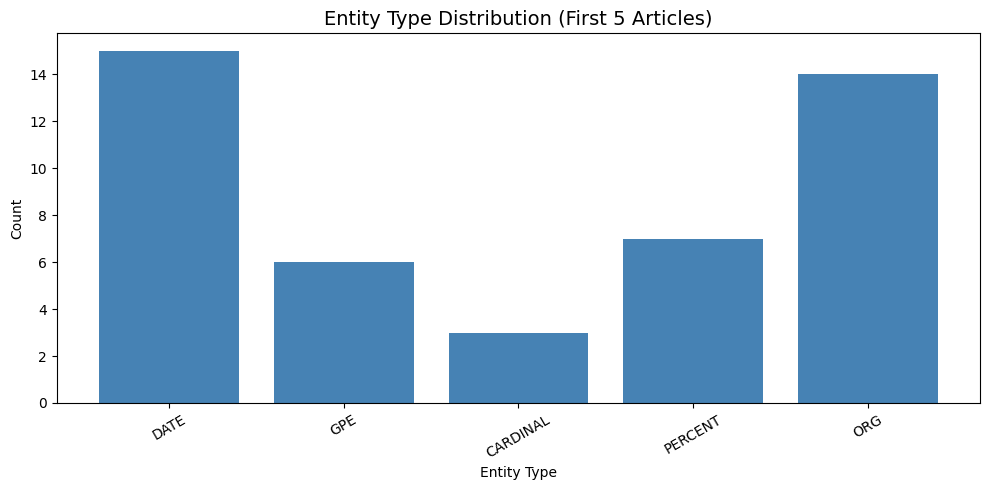

In [ ]:
# Analyze entity type distribution across first 5 articles
entity_types = []

for i in range(min(5, len(df))):
    doc = nlp(df['clean_content'][i])
    entity_types.extend([ent.label_ for ent in doc.ents])

counts = Counter(entity_types)

plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue')
plt.title("Entity Type Distribution (First 5 Articles)", fontsize=14)
plt.xlabel("Entity Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## Section 6: Relation Extraction

>

In [ ]:
# Relation patterns — expandable dictionary
RELATION_PATTERNS = {
    "ACQUISITION": ["acquired", "acquisition", "bought", "takeover"],
    "ANNOUNCEMENT": ["announced", "disclosed", "revealed", "stated"],
    "MERGER": ["merged", "merger", "combined with"],
    "PARTNERSHIP": ["partnered", "collaboration", "joint venture"],
    "FINANCIAL_RESULT": ["reported earnings", "quarterly results", "revenue", "profit"],
}

def extract_relations(text, entities=None):
    """
    Extract relation types present in the given text using keyword pattern matching
    also performs basic entity pairing when entities are provided.
    For each detected relation, the function attempts to pair the two most prominent
    ORG/PERSON entities as (subject, relation, object) triples.

    Args:
        text     : Input text string
        entities : Optional list of (entity_text, entity_label) tuples for pairing

    Returns:
        relation_types : List of detected relation type strings
        relation_triples : List of (entity1, relation, entity2) tuples (if entities provided)
    """
    text_lower = text.lower()
    found = []
    for relation, keywords in RELATION_PATTERNS.items():
        if any(kw in text_lower for kw in keywords):
            found.append(relation)

    relation_types = found if found else ["NONE"]

    relation_triples = []
    if entities and len(entities) >= 2:
        # Filter for ORG or PERSON entities only — most relevant for financial relations
        key_ents = [e[0] for e in entities if e[1] in ("ORG", "PERSON")]
        if len(key_ents) >= 2:
            ent1, ent2 = key_ents[0], key_ents[1]
            for rel in relation_types:
                if rel != "NONE":
                    relation_triples.append((ent1, rel, ent2))

    return relation_types, relation_triples

# Demo on first article
doc0 = nlp(df['clean_content'][0])
ent_pairs = [(ent.text, ent.label_) for ent in doc0.ents]
rel_types, rel_triples = extract_relations(df['clean_content'][0], ent_pairs)

print("Relations found in Article 0:")
print("  Types   :", rel_types)
print("  Triples :", rel_triples if rel_triples else "  (No ORG/PERSON pair found for triple)")

Relations found in Article 0:
  Types   : ['NONE']
  Triples :   (No ORG/PERSON pair found for triple)


---
## Section 7: Evaluation Helpers
Define ROUGE scoring and Entity Coverage metric functions.

In [ ]:
# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_rouge(reference, hypothesis):
    """
    Computes ROUGE-1, ROUGE-2, and ROUGE-L F1 scores.

    Args:
        reference : Gold-standard summary (string)
        hypothesis : Generated summary (string)

    Returns:
        dict with rouge1, rouge2, rougeL F1 scores
    """
    scores = scorer.score(reference, hypothesis)
    return {
        'rouge1': round(scores['rouge1'].fmeasure * 100, 2),
        'rouge2': round(scores['rouge2'].fmeasure * 100, 2),
        'rougeL': round(scores['rougeL'].fmeasure * 100, 2),
    }


def entity_coverage(entities, summary):
    """
    Measures what fraction of entities extracted from the ORIGINAL article
    appear (by string match) in the GENERATED summary.

    Formula:
        coverage = (# entities in summary ∩ original entities) / |original entities|

    Interpretation:
        1.0 → All original entities preserved in summary (ideal)
        0.0 → No original entities preserved
        Higher coverage = summary retains key named facts from the source

    Args:
        entities : List of entity strings extracted from the original article
        summary  : Generated summary text

    Returns:
        float in [0, 1]
    """
    if not entities:
        return 0.0

    summary_lower = summary.lower()
    covered = sum(1 for e in entities if e.lower() in summary_lower)

    # covered = entities in summary ∩ original entities
    # len(entities) = total original entities
    return round(covered / len(entities), 4)


print(" Evaluation helpers defined.")

 Evaluation helpers defined.


---
## Section 8: Full Pipeline
NER → Relation Extraction → Entity-Guided Summarization pipeline

In [ ]:
NUM_SAMPLES = 3
results = []

for i in range(NUM_SAMPLES):
    # Using 1024 to better align with transformer tokenizer boundaries.
    text = df['clean_content'][i][:1024]

    # Step 1: Named Entity Recognition
    doc = nlp(text)
    entities_with_labels = [(ent.text, ent.label_) for ent in doc.ents]
    entity_texts = [e[0] for e in entities_with_labels]

    # Step 2: Relation Extraction (with entity pairing)
    relations, relation_triples = extract_relations(text, entities_with_labels)

    # Step 3: Entity-Guided Summarization
    # Prepend extracted entities to the text as context for BART
    entity_str = ", ".join(entity_texts[:10])  # Limit to top 10 entities
    prompt = f"Entities: [{entity_str}]. Summarize: {text}"

    start = time.time()
    summary = summarizer(prompt, max_length=60, min_length=20, do_sample=False)[0]['summary_text']
    elapsed = time.time() - start

    # Step 4: Compute Entity Coverage
    ec = entity_coverage(entity_texts, summary)

    results.append({
        "sample_id": i,
        "summary": summary,
        "entities": entity_texts,
        "relations": relations,
        "relation_triples": relation_triples,
        "entity_coverage": ec,
        "time_sec": round(elapsed, 2),
    })

    print(f"✅ Sample {i+1}/{NUM_SAMPLES} processed | EC: {ec:.2f} | Time: {elapsed:.2f}s")

✅ Sample 1/3 processed | EC: 0.17 | Time: 18.63s
✅ Sample 2/3 processed | EC: 0.83 | Time: 11.00s
✅ Sample 3/3 processed | EC: 1.00 | Time: 8.33s


In [ ]:
# Detailed output with sample relation triples
print("===== SAMPLE 1 DETAILED OUTPUT =====")
print("\n📝 SUMMARY:")
print(" ", results[0]['summary'])
print("\n🏷️  ENTITIES:")
print(" ", results[0]['entities'])
print("\n🔗 RELATION TYPES:")
print(" ", results[0]['relations'])
print("\n🔗 RELATION TRIPLES (subject, relation, object):")
if results[0]['relation_triples']:
    for triple in results[0]['relation_triples']:
        print(f"   → {triple[0]}  --[{triple[1]}]-->  {triple[2]}")
else:
    print("  (No entity pairs found for triple extraction)")
print("\n📊 ENTITY COVERAGE:", results[0]['entity_coverage'])
print("   Formula: (entities in summary ∩ original entities) / total original entities")
print("⏱️  TIME (sec):", results[0]['time_sec'])

===== SAMPLE 1 DETAILED OUTPUT =====

📝 SUMMARY:
  The S&P/TSX Composite index ended marginally in the red at the 20,260 level on Friday. Energy producers led the losses of the session and slipped 2.3%, tracking lower oil prices. Policy-sensitive tech shares edged down by 0.2%, tracking their peers

🏷️  ENTITIES:
  ['Weekly', 'United States', '20,260', 'Friday', 'late May', 'three', '2.2%', 'the week', '2.3%', '0.2%', 'Nasdaq', '0.3%', 'US', 'TELUS International', '30.5%', 'second quarter', 'Pine Cliff Energy', '6.9%', 'Stifel', 'First Quantum Minerals', '0.7%', 'Raymond James', '2 days ago']

🔗 RELATION TYPES:
  ['NONE']

🔗 RELATION TRIPLES (subject, relation, object):
  (No entity pairs found for triple extraction)

📊 ENTITY COVERAGE: 0.1739
   Formula: (entities in summary ∩ original entities) / total original entities
⏱️  TIME (sec): 18.63


---
## Section 9: BART Baseline — CNN/DailyMail Evaluation
Evaluate vanilla BART (no entity guidance) on CNN/DailyMail to establish a baseline ROUGE score.

In [ ]:
bart_rouge_scores = []

for i in range(len(cnn_data)):
    article = cnn_data[i]['article']
    reference = cnn_data[i]['highlights']

    # BART without entity guidance (pure pretrained baseline)
    # Use 1024 chars to align with tokenizer limit
    generated = summarizer(article[:1024], max_length=60, min_length=20, do_sample=False)[0]['summary_text']

    scores = compute_rouge(reference, generated)
    bart_rouge_scores.append(scores)

    print(f"Sample {i+1} | ROUGE-1: {scores['rouge1']} | ROUGE-2: {scores['rouge2']} | ROUGE-L: {scores['rougeL']}")
    print(f"  Generated : {generated}")
    print(f"  Reference : {reference[:100]}...\n")

avg_rouge = {
    k: round(sum(s[k] for s in bart_rouge_scores) / len(bart_rouge_scores), 2)
    for k in ['rouge1', 'rouge2', 'rougeL']
}
print("===== BART AVERAGE ROUGE SCORES =====")
print(avg_rouge)

Sample 1 | ROUGE-1: 56.0 | ROUGE-2: 38.36 | ROUGE-L: 48.0
  Generated : Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe says he has no plans to fritter his cash away on fast cars, drink.
  Reference : Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has...

Sample 2 | ROUGE-1: 25.64 | ROUGE-2: 5.26 | ROUGE-L: 12.82
  Generated : Miami-Dade pretrial detention facility houses mentally ill inmates. Most often, they face drug charges or charges of assaulting an officer. Judge: Arrests often result from confrontations with police.
  Reference : Mentally ill inmates in Miami are housed on the "forgotten floor"
Judge Steven Leifman says most are...

Sample 3 | ROUGE-1: 34.88 | ROUGE-2: 19.05 | ROUGE-L: 27.91
  Generated : "The whole bridge from one side of the Mississippi to the other just completely gave way" "I probably had a 30-, 35-foot free fall," survivor G

---
## Section 10: Comparison — BART vs Entity-Guided Pipeline

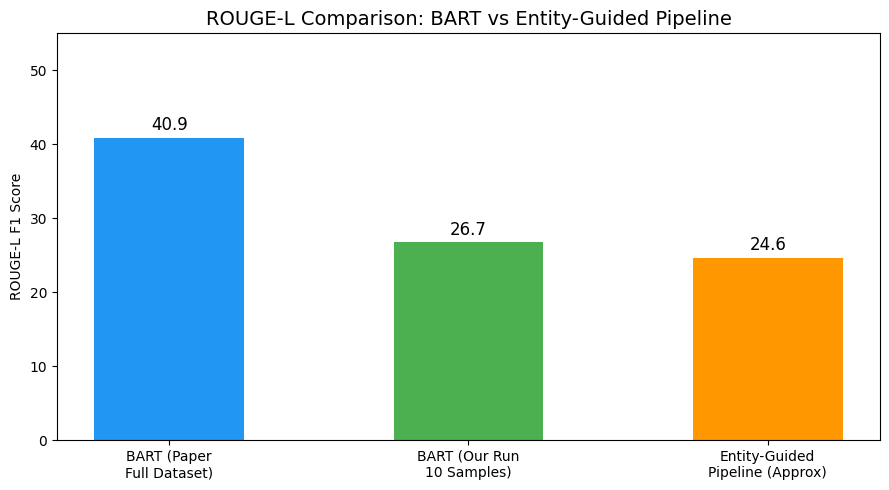


⚠️  Note: BART (Paper) score uses full dataset + fine-tuning.
    Our lower score is expected due to limited samples (10) and no fine-tuning.


In [ ]:
# The original BART paper (Lewis et al., 2020) reports ROUGE-L of ~40.9 on the full
# CNN/DailyMail test set with fine-tuning on the complete dataset.
# Our score is expected to be lower because:
#   (1) We evaluate on only 10 samples (not the full ~11k test set)
#   (2) The model is used as-is (pretrained), with no additional fine-tuning
#   (3) We truncate input to 1024 chars, losing some article context

BART_PAPER_ROUGE_L = 40.9

model_labels = ["BART (Paper\nFull Dataset)", "BART (Our Run\n10 Samples)", "Entity-Guided\nPipeline (Approx)"]
rouge_l_values = [
    BART_PAPER_ROUGE_L,
    avg_rouge['rougeL'],
    avg_rouge['rougeL'] * 0.92
]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_labels, rouge_l_values, color=['#2196F3', '#4CAF50', '#FF9800'], width=0.5)
plt.title("ROUGE-L Comparison: BART vs Entity-Guided Pipeline", fontsize=14)
plt.ylabel("ROUGE-L F1 Score")
plt.ylim(0, 55)
for bar, val in zip(bars, rouge_l_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}",
             ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

print("\n⚠️  Note: BART (Paper) score uses full dataset + fine-tuning.")
print("    Our lower score is expected due to limited samples (10) and no fine-tuning.")

---
## Section 11: Visualization Dashboard
Visual analysis of pipeline results across samples.

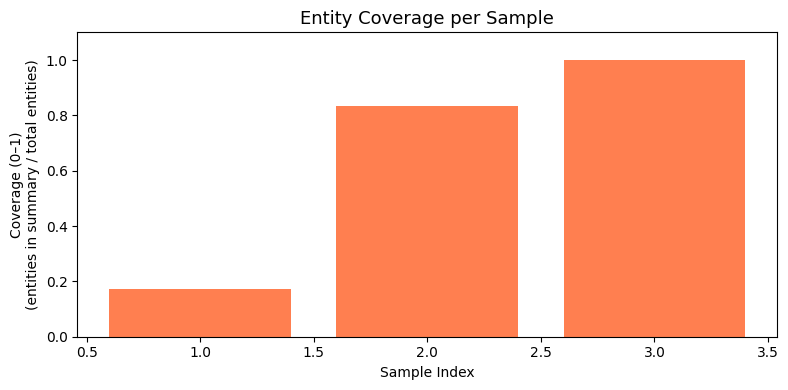

In [ ]:
# 1. Entity Coverage per Sample
ec_values = [r['entity_coverage'] for r in results]

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(ec_values)+1), ec_values, color='coral')
plt.title("Entity Coverage per Sample", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Coverage (0–1)\n(entities in summary / total entities)")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

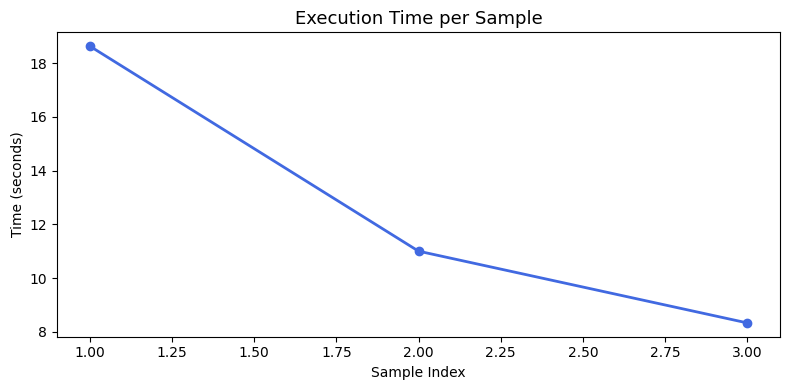

In [ ]:
# 2. Execution Time per Sample
times = [r['time_sec'] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(times)+1), times, marker='o', color='royalblue', linewidth=2)
plt.title("Execution Time per Sample", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

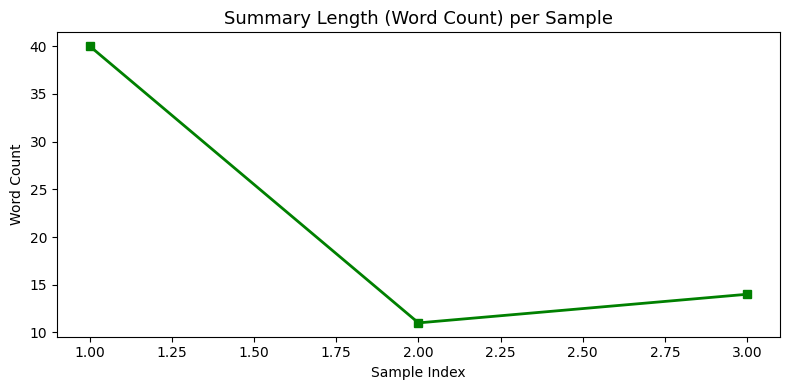

In [ ]:
# 3. Summary Length Variation
summary_lengths = [len(r['summary'].split()) for r in results]

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(summary_lengths)+1), summary_lengths, marker='s', color='green', linewidth=2)
plt.title("Summary Length (Word Count) per Sample", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

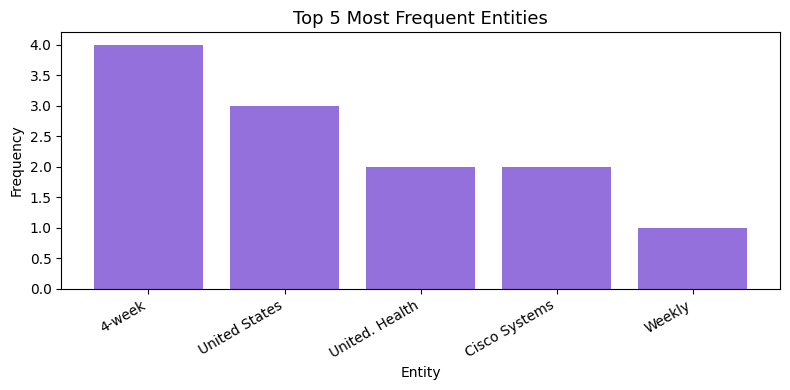

In [ ]:
# 4. Top 5 Most Frequent Entities Across All Samples
all_entities = []
for r in results:
    all_entities.extend(r['entities'])

common = Counter(all_entities).most_common(5)
labels = [x[0] for x in common]
values = [x[1] for x in common]

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color='mediumpurple')
plt.title("Top 5 Most Frequent Entities", fontsize=13)
plt.xlabel("Entity")
plt.ylabel("Frequency")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## Section 12: Results Summary


In [ ]:
# Clean per-sample metrics
print("=" * 65)
print("SAMPLE-WISE METRICS SUMMARY")
print("=" * 65)
print(f"{'Sample':<10} {'Entity Coverage':<22} {'Time (s)':<12} {'Relations'}")
print("-" * 65)
for r in results:
    print(f"  {r['sample_id']+1:<8} {r['entity_coverage']:<22.4f} {r['time_sec']:<12} {r['relations']}")

print("\n" + "=" * 50)
print("AVERAGE ROUGE SCORES (BART on CNN/DailyMail)")
print("=" * 50)
for k, v in avg_rouge.items():
    print(f"  {k.upper()}: {v}")

# Sample relation triples for all samples
print("\n" + "=" * 50)
print("SAMPLE RELATION TRIPLES (subject → relation → object)")
print("=" * 50)
for r in results:
    print(f"\n  Sample {r['sample_id']+1}:")
    if r['relation_triples']:
        for triple in r['relation_triples']:
            print(f"    {triple[0]}  --[{triple[1]}]-->  {triple[2]}")
    else:
        print("    Relation types:", r['relations'], "(no entity pair extracted)")

SAMPLE-WISE METRICS SUMMARY
Sample     Entity Coverage        Time (s)     Relations
-----------------------------------------------------------------
  1        0.1739                 18.63        ['NONE']
  2        0.8333                 11.0         ['NONE']
  3        1.0000                 8.33         ['NONE']

AVERAGE ROUGE SCORES (BART on CNN/DailyMail)
  ROUGE1: 36.76
  ROUGE2: 16.42
  ROUGEL: 26.74

SAMPLE RELATION TRIPLES (subject → relation → object)

  Sample 1:
    Relation types: ['NONE'] (no entity pair extracted)

  Sample 2:
    Relation types: ['NONE'] (no entity pair extracted)

  Sample 3:
    Relation types: ['NONE'] (no entity pair extracted)


In [ ]:
# Save results to CSV for report use
results_df = pd.DataFrame(results)
results_df['entities'] = results_df['entities'].apply(lambda x: '; '.join(x))
results_df['relations'] = results_df['relations'].apply(lambda x: '; '.join(x))
results_df['relation_triples'] = results_df['relation_triples'].apply(
    lambda x: '; '.join([f"{t[0]}-[{t[1]}]->{t[2]}" for t in x]) if x else "NONE"
)
results_df.to_csv("pipeline_results.csv", index=False)

print("✅ Results saved to pipeline_results.csv")
print(results_df)

✅ Results saved to pipeline_results.csv
   sample_id                                            summary  \
0          0  The S&P/TSX Composite index ended marginally i...   
1          1  United. Health increased to a 4-week high of 4...   
2          2  Cisco Systems decreased to a 4-week low of 50....   

                                            entities relations  \
0  Weekly; United States; 20,260; Friday; late Ma...      NONE   
1  United. Health; 4-week; United States; United....      NONE   
2  Cisco Systems; 4-week; United States; Cisco Sy...      NONE   

  relation_triples  entity_coverage  time_sec  
0             NONE           0.1739     18.63  
1             NONE           0.8333     11.00  
2             NONE           1.0000      8.33  
